In [3]:


import numpy as np
import pandas as pd
import re
import datetime

In [4]:
# Install Faker if not installed
!pip install faker

import pandas as pd
import random
from datetime import datetime, timedelta
from faker import Faker

# Initialize Faker
faker = Faker()


# -------------------------------
# LOG GENERATOR
# -------------------------------
def generate_synthetic_log(
    log_type,
    ip=None,
    username=None,
    timestamp=None,
    target_ip=None,
    filename=None
):
    ip = ip if ip else faker.ipv4_public()
    username = username if username else faker.user_name()
    timestamp_dt = timestamp if timestamp else faker.date_time_between(start_date='-5y', end_date='now')
    timestamp_str = timestamp_dt.strftime('%a %b %d %H:%M:%S %Y')
    resource = faker.uri_path()

    if log_type == 'authentication-failed':
        return {
            'category': 'authentication-failed',
            'log': f"[{timestamp_str}] [error] [client {ip}] user {username}: authentication failure for \"{resource}\", reason: user not found"
        }

    elif log_type == 'http-request-failure':
        status_code = random.choice([401, 403, 404, 500, 502])
        user_agent = faker.user_agent()
        method = random.choice(['GET', 'POST', 'PUT'])
        return {
            'category': 'http-request-failure',
            'log': f"[{timestamp_str}] [error] [client {ip}] {method} {resource} HTTP/1.1 \"{user_agent}\" {status_code}"
        }

    elif log_type == 'process-info':
        process_name = faker.file_name(extension='exe')
        pid = random.randint(1000, 9999)
        message = faker.sentence()
        return {
            'category': 'process-info',
            'log': f"[{timestamp_str}] [notice] process {process_name}[{pid}]: {message}"
        }

    elif log_type == 'user-session-open':
        session_id = faker.uuid4()
        return {
            'category': 'user-session-open',
            'log': f"[{timestamp_str}] [info] user {username}: session {session_id} opened from {ip}"
        }

    elif log_type == 'network-scan':
        target_ip_val = target_ip if target_ip else faker.ipv4_private()
        port = random.randint(1, 65535)
        return {
            'category': 'network-scan',
            'log': f"[{timestamp_str}] [alert] [source {ip}] detected port scan from {ip} to {target_ip_val} on port {port}"
        }

    elif log_type == 'malware-detection':
        filename_val = filename if filename else faker.file_name()
        malware_name = faker.word()
        return {
            'category': 'malware-detection',
            'log': f"[{timestamp_str}] [critical] [host {ip}] malware detected: {malware_name} in {filename_val}"
        }

    elif log_type == 'data-exfiltration':
        data_size = random.randint(10, 1000)
        protocol = random.choice(['FTP', 'HTTP', 'HTTPS'])
        return {
            'category': 'data-exfiltration',
            'log': f"[{timestamp_str}] [warning] [source {ip}] potential data exfiltration of {data_size}MB via {protocol} to {faker.url()}"
        }

    # ✅ NEW PHISHING LOG
    elif log_type == 'phishing-email':
        sender = faker.email()
        subject = random.choice([
            "Urgent: Password Reset Required",
            "Invoice Attached",
            "Security Alert",
            "Account Suspension Notice"
        ])
        malicious_url = faker.url()

        return {
            'category': 'phishing-email',
            'log': f"[{timestamp_str}] [warning] email received by {username} from {sender} with subject '{subject}' containing suspicious link {malicious_url}"
        }

    else:
        return {
            'category': 'generic',
            'log': f"[{timestamp_str}] [info] [client {ip}] generic log entry: {faker.sentence()}"
        }


# -------------------------------
# DATASET GENERATOR
# -------------------------------
def generate_synthetic_logs_df(num_logs=50000, num_scenarios=200):

    logs_data = []

    all_log_types = [
        'authentication-failed',
        'http-request-failure',
        'process-info',
        'user-session-open',
        'network-scan',
        'malware-detection',
        'data-exfiltration',
        'phishing-email'  # ✅ added
    ]

    for _ in range(num_scenarios):

        scenario_type = random.choice([
            'brute-force',
            'scan-exploit',
            'malware-chain',
            'data-theft',
            'phishing-compromise'  # ✅ NEW
        ])

        source_ip = faker.ipv4_public()
        source_username = faker.user_name()
        scenario_start_time = faker.date_time_between(start_date='-5y', end_date='now')

        # ---------------- brute force
        if scenario_type == 'brute-force':
            for i in range(random.randint(3, 10)):
                log_time = scenario_start_time + timedelta(seconds=i * random.randint(10, 60))
                logs_data.append(generate_synthetic_log(
                    'authentication-failed',
                    ip=source_ip,
                    username=source_username,
                    timestamp=log_time
                ))

        # ---------------- scan exploit
        elif scenario_type == 'scan-exploit':
            target_ip = faker.ipv4_private()

            logs_data.append(generate_synthetic_log(
                'network-scan',
                ip=source_ip,
                timestamp=scenario_start_time,
                target_ip=target_ip
            ))

            logs_data.append(generate_synthetic_log(
                'http-request-failure',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time + timedelta(minutes=random.randint(1, 10))
            ))

        # ---------------- malware chain
        elif scenario_type == 'malware-chain':
            logs_data.append(generate_synthetic_log(
                'user-session-open',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time
            ))

            logs_data.append(generate_synthetic_log(
                'process-info',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time + timedelta(minutes=random.randint(5, 20))
            ))

            logs_data.append(generate_synthetic_log(
                'malware-detection',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time + timedelta(minutes=random.randint(20, 60)),
                filename=faker.file_name(extension='dll')
            ))

        # ---------------- data theft
        elif scenario_type == 'data-theft':
            logs_data.append(generate_synthetic_log(
                'user-session-open',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time
            ))

            logs_data.append(generate_synthetic_log(
                'data-exfiltration',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time + timedelta(minutes=random.randint(10, 45))
            ))

        # ---------------- ✅ PHISHING ATTACK CHAIN
        elif scenario_type == 'phishing-compromise':

            # phishing email
            logs_data.append(generate_synthetic_log(
                'phishing-email',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time
            ))

            # login after click
            logs_data.append(generate_synthetic_log(
                'user-session-open',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time + timedelta(minutes=random.randint(2, 15))
            ))

            # malware execution
            logs_data.append(generate_synthetic_log(
                'malware-detection',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time + timedelta(minutes=random.randint(15, 40))
            ))

            # data exfiltration
            logs_data.append(generate_synthetic_log(
                'data-exfiltration',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time + timedelta(minutes=random.randint(40, 90))
            ))

    # Fill remaining logs randomly
    remaining_logs_count = num_logs - len(logs_data)

    for _ in range(remaining_logs_count):
        logs_data.append(generate_synthetic_log(random.choice(all_log_types)))

    return pd.DataFrame(logs_data)


# -------------------------------
# GENERATE DATA
# -------------------------------
df = generate_synthetic_logs_df(num_logs=50000, num_scenarios=200)

print(df.shape)
df.head()



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
(50000, 2)


,category,log
0,authentication-failed,[Thu Oct 30 15:06:33 2025] [error] [client 210...
1,authentication-failed,[Thu Oct 30 15:07:04 2025] [error] [client 210...
2,authentication-failed,[Thu Oct 30 15:07:11 2025] [error] [client 210...
3,user-session-open,[Sun Nov 23 18:46:04 2025] [info] user robert4...
4,process-info,[Sun Nov 23 19:02:04 2025] [notice] process ac...


In [5]:
import pandas as pd
import re
from datetime import datetime

def flexible_log_parser(df):
    """Parse logs with flexible pattern matching"""

    results = []

    for idx, row in df.iterrows():
        try:
            log_text = row['log']
            category = row['category']

            # Extract timestamp - everything between first [ and ]
            timestamp_match = re.search(r'\[(.*?)\]', log_text)
            if not timestamp_match:
                continue

            date_str = timestamp_match.group(1)

            # Try to parse the date
            try:
                # Try different date formats
                if len(date_str.split()) == 5:  # "Thu Dec 17 02:47:06 1992"
                    dt = datetime.strptime(date_str, '%a %b %d %H:%M:%S %Y')
                elif len(date_str.split()) == 4:  # "Dec 17 02:47:06 1992"
                    dt = datetime.strptime(date_str, '%b %d %H:%M:%S %Y')
                else:
                    continue
            except:
                continue

            # Extract IP - look for "client X.X.X.X", "source X.X.X.X", or "host X.X.X.X"
            ip_match = re.search(r'(?:client|source|host)\s+([\d.]+)', log_text)
            ip = ip_match.group(1) if ip_match else 'unknown'

            # Extract username - look for "user name:"
            user_match = re.search(r'user (\w+):', log_text)
            username = user_match.group(1) if user_match else 'unknown'

            # Extract resource - look for "/something"
            resource_match = re.search(r'"(/[^\"]+)"', log_text)
            resource = resource_match.group(1) if resource_match else 'unknown'

            results.append({
                'timestamp': dt.isoformat() + 'Z',
                'source_ip': ip,
                'username': username,
                'resource': resource,
                'category': category,
                'year': dt.year,
                'month': dt.month,
                'day': dt.day,
                'hour': dt.hour,
                'minute': dt.minute,
                'second': dt.second,
                'weekday': dt.strftime('%a'),
                'raw_log': log_text[:100]  # For debugging
            })

        except Exception as e:
            continue

    return pd.DataFrame(results)

# Run it
df_parsed = flexible_log_parser(df)
df_parsed.head()

,timestamp,source_ip,username,resource,category,year,month,day,hour,minute,second,weekday,raw_log
0,2025-10-30T15:06:33Z,210.255.24.197,colleenbanks,unknown,authentication-failed,2025,10,30,15,6,33,Thu,[Thu Oct 30 15:06:33 2025] [error] [client 210...
1,2025-10-30T15:07:04Z,210.255.24.197,colleenbanks,unknown,authentication-failed,2025,10,30,15,7,4,Thu,[Thu Oct 30 15:07:04 2025] [error] [client 210...
2,2025-10-30T15:07:11Z,210.255.24.197,colleenbanks,unknown,authentication-failed,2025,10,30,15,7,11,Thu,[Thu Oct 30 15:07:11 2025] [error] [client 210...
3,2025-11-23T18:46:04Z,unknown,robert44,unknown,user-session-open,2025,11,23,18,46,4,Sun,[Sun Nov 23 18:46:04 2025] [info] user robert4...
4,2025-11-23T19:02:04Z,unknown,unknown,unknown,process-info,2025,11,23,19,2,4,Sun,[Sun Nov 23 19:02:04 2025] [notice] process ac...


In [6]:
df_parsed.head(n=10)

,timestamp,source_ip,username,resource,category,year,month,day,hour,minute,second,weekday,raw_log
0,2025-10-30T15:06:33Z,210.255.24.197,colleenbanks,unknown,authentication-failed,2025,10,30,15,6,33,Thu,[Thu Oct 30 15:06:33 2025] [error] [client 210...
1,2025-10-30T15:07:04Z,210.255.24.197,colleenbanks,unknown,authentication-failed,2025,10,30,15,7,4,Thu,[Thu Oct 30 15:07:04 2025] [error] [client 210...
2,2025-10-30T15:07:11Z,210.255.24.197,colleenbanks,unknown,authentication-failed,2025,10,30,15,7,11,Thu,[Thu Oct 30 15:07:11 2025] [error] [client 210...
3,2025-11-23T18:46:04Z,unknown,robert44,unknown,user-session-open,2025,11,23,18,46,4,Sun,[Sun Nov 23 18:46:04 2025] [info] user robert4...
4,2025-11-23T19:02:04Z,unknown,unknown,unknown,process-info,2025,11,23,19,2,4,Sun,[Sun Nov 23 19:02:04 2025] [notice] process ac...
5,2025-11-23T19:17:04Z,87.186.87.35,unknown,unknown,malware-detection,2025,11,23,19,17,4,Sun,[Sun Nov 23 19:17:04 2025] [critical] [host 87...
6,2023-06-05T18:38:38Z,unknown,priscilla11,unknown,user-session-open,2023,6,5,18,38,38,Mon,[Mon Jun 05 18:38:38 2023] [info] user priscil...
7,2023-06-05T18:49:38Z,unknown,unknown,unknown,process-info,2023,6,5,18,49,38,Mon,[Mon Jun 05 18:49:38 2023] [notice] process co...
8,2023-06-05T19:02:38Z,192.123.139.230,unknown,unknown,malware-detection,2023,6,5,19,2,38,Mon,[Mon Jun 05 19:02:38 2023] [critical] [host 19...
9,2021-10-26T04:24:10Z,131.179.86.11,unknown,unknown,network-scan,2021,10,26,4,24,10,Tue,[Tue Oct 26 04:24:10 2021] [alert] [source 131...


In [7]:
df_parsed.shape

(50000, 13)

In [8]:
def group_into_events(df, time_window_minutes=5):
    """
    Group related logs into security events based on:
    - Time proximity
    - Same source/category
    - Sequential patterns
    """

    # Sort by timestamp
    df = df.sort_values('timestamp').reset_index(drop=True)

    events = []
    current_event = None

    for idx, row in df.iterrows():
        if current_event is None:
            # Start new event
            current_event = {
                'event_id': len(events) + 1,
                'start_time': row['timestamp'],
                'end_time': row['timestamp'],
                'source_ip': row['source_ip'],
                'username': row['username'],
                'resource': row['resource'],
                'category': row['category'],
                'log_count': 1,
                'log_indices': [idx],
                'severity_score': 0,
                'raw_samples': [row['raw_log'][:200]]  # First 200 chars
            }
        else:
            # Check if this log belongs to current event
            time_diff = (pd.to_datetime(row['timestamp']) -
                        pd.to_datetime(current_event['end_time'])).total_seconds() / 60

            same_source = (row['source_ip'] == current_event['source_ip'] or
                          row['username'] == current_event['username'])

            same_category = (row['category'] == current_event['category'])

            # Belongs to same event if within time window AND (same source or category)
            if time_diff <= time_window_minutes and (same_source or same_category):
                current_event['end_time'] = row['timestamp']
                current_event['log_count'] += 1
                current_event['log_indices'].append(idx)
                if len(current_event['raw_samples']) < 3:  # Keep max 3 samples
                    current_event['raw_samples'].append(row['raw_log'][:200])
            else:
                # Save current event and start new one
                events.append(current_event)
                current_event = {
                    'event_id': len(events) + 1,
                    'start_time': row['timestamp'],
                    'end_time': row['timestamp'],
                    'source_ip': row['source_ip'],
                    'username': row['username'],
                    'resource': row['resource'],
                    'category': row['category'],
                    'log_count': 1,
                    'log_indices': [idx],
                    'severity_score': 0,
                    'raw_samples': [row['raw_log'][:200]]
                }

    # Don't forget the last event
    if current_event:
        events.append(current_event)

    return pd.DataFrame(events)

# Group your logs
events_df = group_into_events(df_parsed)
# events_df = events_df.sort_values('log_count').reset_index(drop=True)

events_df.sample(n=10)

,event_id,start_time,end_time,source_ip,username,resource,category,log_count,log_indices,severity_score,raw_samples
23248,23249,2023-08-13T02:42:01Z,2023-08-13T02:42:01Z,unknown,jowen,unknown,user-session-open,1,[24818],0,[[Sun Aug 13 02:42:01 2023] [info] user jowen:...
14351,14352,2022-08-31T13:07:50Z,2022-08-31T13:07:50Z,183.120.206.37,unknown,unknown,malware-detection,1,[15277],0,[[Wed Aug 31 13:07:50 2022] [critical] [host 1...
11735,11736,2022-05-23T06:05:27Z,2022-05-23T06:05:27Z,unknown,unknown,unknown,phishing-email,1,[12493],0,[[Mon May 23 06:05:27 2022] [warning] email re...
16820,16821,2022-12-06T14:14:40Z,2022-12-06T14:14:40Z,unknown,unknown,unknown,phishing-email,1,[17942],0,[[Tue Dec 06 14:14:40 2022] [warning] email re...
29148,29149,2024-03-30T04:08:35Z,2024-03-30T04:08:35Z,121.126.34.132,unknown,unknown,http-request-failure,1,[31132],0,[[Sat Mar 30 04:08:35 2024] [error] [client 12...
26373,26374,2023-12-14T04:20:54Z,2023-12-14T04:20:54Z,61.235.66.2,unknown,unknown,malware-detection,1,[28175],0,[[Thu Dec 14 04:20:54 2023] [critical] [host 6...
23791,23792,2023-09-03T08:08:09Z,2023-09-03T08:08:09Z,192.241.207.185,unknown,unknown,malware-detection,1,[25390],0,[[Sun Sep 03 08:08:09 2023] [critical] [host 1...
38991,38992,2025-04-21T05:33:48Z,2025-04-21T05:33:48Z,unknown,unknown,unknown,process-info,1,[41607],0,[[Mon Apr 21 05:33:48 2025] [notice] process t...
11705,11706,2022-05-22T00:24:29Z,2022-05-22T00:24:29Z,95.40.117.69,unknown,unknown,network-scan,1,[12462],0,[[Sun May 22 00:24:29 2022] [alert] [source 95...
5742,5743,2021-10-03T14:40:27Z,2021-10-03T14:40:27Z,190.41.179.153,unknown,unknown,malware-detection,1,[6117],0,[[Sun Oct 03 14:40:27 2021] [critical] [host 1...


In [9]:
events_df.shape

(46835, 11)


Events by Category:
category
user-session-open        6139
authentication-failed    6093
malware-detection        5924
process-info             5870
data-exfiltration        5737
phishing-email           5715
http-request-failure     5684
network-scan             5673
Name: count, dtype: int64

Average Score by Category:
category
authentication-failed    0.0
data-exfiltration        0.0
http-request-failure     0.0
malware-detection        0.0
network-scan             0.0
phishing-email           0.0
process-info             0.0
user-session-open        0.0
Name: severity_score, dtype: float64


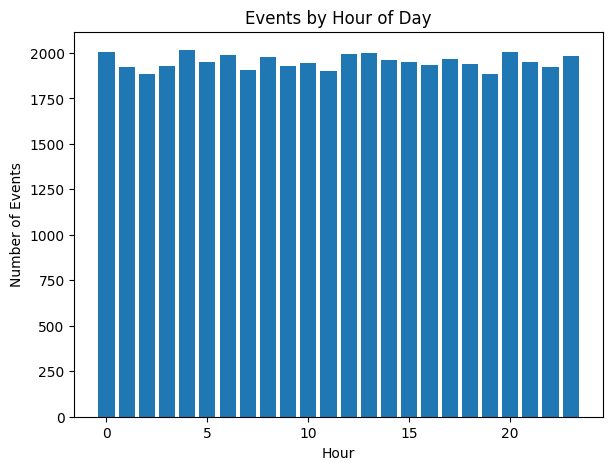

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Events over time
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
events_by_hour = pd.to_datetime(events_df['start_time']).dt.hour.value_counts().sort_index()
plt.bar(events_by_hour.index, events_by_hour.values)
plt.title('Events by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Events')

# Category breakdown
print("\nEvents by Category:")
print(events_df['category'].value_counts())

print("\nAverage Score by Category:")
print(events_df.groupby('category')['severity_score'].mean().sort_values(ascending=False))

In [11]:
import pandas as pd
import numpy as np
from datetime import timedelta
from collections import defaultdict
import networkx as nx

def temporal_correlation(events_df, time_window_minutes=30):
    """
    Find events that occur close together in time
    """
    events_df = events_df.copy()
    events_df['start_dt'] = pd.to_datetime(events_df['start_time'])
    events_df = events_df.sort_values('start_dt')

    correlations = []

    for i, event1 in events_df.iterrows():
        # Find events within time window after this event
        time_mask = (
            (events_df['start_dt'] > event1['start_dt']) &
            (events_df['start_dt'] <= event1['start_dt'] + timedelta(minutes=time_window_minutes))
        )

        following_events = events_df[time_mask]

        for j, event2 in following_events.iterrows():
            correlation = {
                'source_event': event1['event_id'],
                'target_event': event2['event_id'],
                'time_diff_minutes': (event2['start_dt'] - event1['start_dt']).total_seconds() / 60,
                'source_category': event1['category'],
                'target_category': event2['category'],
                'source_ip': event1['source_ip'],
                'target_ip': event2['source_ip'],
                'username': event1['username'] if event1['username'] == event2['username'] else 'different',
                'correlation_type': 'temporal',
                'confidence': 0.6  # Base confidence
            }

            # Boost confidence if same source/user
            if event1['source_ip'] == event2['source_ip'] and event1['source_ip'] != 'unknown':
                correlation['confidence'] += 0.3
            if event1['username'] == event2['username'] and event1['username'] != 'unknown':
                correlation['confidence'] += 0.2

            correlations.append(correlation)

    return pd.DataFrame(correlations)

# Run temporal correlation
temporal_corr = temporal_correlation(events_df)
temporal_corr.head()

,source_event,target_event,time_diff_minutes,source_category,target_category,source_ip,target_ip,username,correlation_type,confidence
0,1,2,10.350000,user-session-open,http-request-failure,unknown,125.93.60.227,different,temporal,0.6
1,8,9,3.883333,http-request-failure,authentication-failed,70.4.73.153,206.133.21.238,different,temporal,0.6
2,12,13,28.116667,data-exfiltration,phishing-email,208.243.191.196,unknown,unknown,temporal,0.6
3,13,14,10.950000,phishing-email,network-scan,unknown,210.176.191.3,unknown,temporal,0.6
4,18,19,25.116667,user-session-open,authentication-failed,unknown,22.138.57.131,different,temporal,0.6


In [12]:
def kill_chain_correlation(events_df):
    """
    Map events to MITRE ATT&CK kill chain phases
    """

    
    kill_chain_mapping = {
        'process-info': 'execution',
        'authentication-failed': 'credential-access', # Corrected category
        'network-scan': 'reconnaissance', # Added category
        'http-request-failure': 'defense-evasion',
        'malware-detection': 'execution', # Added category
        'data-exfiltration': 'exfiltration', # Added category
        'user-session-open': 'initial-access' # Added category
    }

    events_df = events_df.copy()
    events_df['kill_chain_phase'] = events_df['category'].map(
        lambda x: kill_chain_mapping.get(x, 'unknown')
    )
    events_df['start_dt'] = pd.to_datetime(events_df['start_time'])

    # Group by source IP to find attack chains
    kill_chain_correlations = []

    for ip in events_df['source_ip'].unique():
        if ip == 'unknown':
            continue

        ip_events = events_df[events_df['source_ip'] == ip].sort_values('start_dt')

        # Track phases seen
        phases_seen = set()
        chain_start = None

        for idx, event in ip_events.iterrows():
            phase = event['kill_chain_phase']

            # If this event's phase is a progression in the chain (not already seen)
            if phase not in phases_seen and phase != 'unknown':
                if len(phases_seen) > 0 and chain_start is not None:
                    # This is a new phase in the attack chain
                    kill_chain_correlations.append({
                        'source_ip': ip,
                        'username': event['username'],
                        'chain_start': chain_start,
                        'current_event': event['event_id'],
                        'current_phase': phase,
                        'phases_completed': list(phases_seen),
                        'phase_count': len(phases_seen) + 1,
                        'time_from_start': (event['start_dt'] - chain_start).total_seconds() / 3600,
                        'confidence': 0.5 + (len(phases_seen) * 0.1),  # More phases = higher confidence
                        'correlation_type': 'kill_chain'
                    })

                phases_seen.add(phase)
                if chain_start is None:
                    chain_start = event['start_dt']

    return pd.DataFrame(kill_chain_correlations)


kill_chain_corr = kill_chain_correlation(events_df)
print(f"Found {len(kill_chain_corr)} kill chain progressions")
print(kill_chain_corr.head())

Found 58 kill chain progressions
        source_ip username               chain_start  current_event  \
0  96.228.195.220  unknown 2021-03-14 08:15:30+00:00            538   
1  103.20.239.163  unknown 2021-04-06 10:16:38+00:00           1145   
2    68.80.37.190  unknown 2021-05-03 19:45:49+00:00           1819   
3  208.225.239.29  unknown 2021-05-06 16:57:17+00:00           1882   
4  198.38.142.195  unknown 2021-06-05 16:30:50+00:00           2702   

  current_phase phases_completed  phase_count  time_from_start  confidence  \
0  exfiltration      [execution]            2         0.483333         0.6   
1  exfiltration      [execution]            2         0.850000         0.6   
2  exfiltration      [execution]            2         0.783333         0.6   
3  exfiltration      [execution]            2         0.283333         0.6   
4  exfiltration      [execution]            2         1.183333         0.6   

  correlation_type  
0       kill_chain  
1       kill_chain  
2       

In [13]:
def pattern_recognition(events_df, min_sequence_length=2):
    """
    Find recurring patterns of event sequences
    """
    from collections import Counter

    events_df = events_df.copy()
    events_df['start_dt'] = pd.to_datetime(events_df['start_time'])

    # Group by source IP and create sequences
    ip_sequences = {}

    for ip in events_df['source_ip'].unique():
        if ip == 'unknown':
            continue

        ip_events = events_df[events_df['source_ip'] == ip].sort_values('start_dt')
        if len(ip_events) >= min_sequence_length:
            # Create category sequence
            sequence = tuple(ip_events['category'].tolist())
            ip_sequences[ip] = {
                'sequence': sequence,
                'events': ip_events['event_id'].tolist(),
                'timestamps': ip_events['start_dt'].tolist()
            }

    # Find common patterns
    all_sequences = [v['sequence'] for v in ip_sequences.values()]
    pattern_counts = Counter(all_sequences)

    # Extract patterns
    patterns = []
    for sequence, count in pattern_counts.items():
        if count >= 2:  # Pattern appears at least twice
            # Find example IPs
            example_ips = [ip for ip, data in ip_sequences.items()
                          if data['sequence'] == sequence][:3]

            patterns.append({
                'pattern': ' → '.join(sequence),
                'frequency': count,
                'example_ips': example_ips,
                'length': len(sequence),
                'confidence': min(0.9, 0.5 + (count * 0.1)),
                'correlation_type': 'pattern'
            })

    return pd.DataFrame(patterns)


patterns_df = pattern_recognition(events_df, min_sequence_length=1)
patterns_df.head()

,pattern,frequency,example_ips,length,confidence,correlation_type
0,http-request-failure,5667,"[125.93.60.227, 129.247.59.104, 70.4.73.153]",1,0.9,pattern
1,authentication-failed,6085,"[73.209.12.179, 206.133.21.238, 22.138.57.131]",1,0.9,pattern
2,network-scan,5656,"[218.140.212.247, 212.65.26.175, 210.176.191.3]",1,0.9,pattern
3,data-exfiltration,5696,"[208.243.191.196, 152.36.17.92, 38.54.99.220]",1,0.9,pattern
4,malware-detection,5883,"[46.83.25.94, 201.146.228.102, 37.229.43.251]",1,0.9,pattern


In [14]:
def entity_correlation(events_df, time_window_hours=8760):
    """
    Correlate events by same actor (IP/username) across different targets
    """
    events_df = events_df.copy()
    events_df['start_dt'] = pd.to_datetime(events_df['start_time'])

    entity_correlations = []

    # Group by source IP
    for entity_type in ['source_ip', 'username']:
        for entity_value in events_df[entity_type].unique():
            if entity_value == 'unknown' or pd.isna(entity_value):
                continue

            entity_events = events_df[events_df[entity_type] == entity_value].sort_values('start_dt')

            if len(entity_events) < 2:
                continue

            # Find distinct targets (resource/destinations)
            unique_targets = entity_events['resource'].nunique()
            unique_categories = entity_events['category'].nunique()
            time_span = (entity_events['start_dt'].max() - entity_events['start_dt'].min()).total_seconds() / 3600

            if unique_targets > 1 or unique_categories > 1:
                entity_correlations.append({
                    'entity_type': entity_type,
                    'entity_value': entity_value,
                    'event_count': len(entity_events),
                    'unique_targets': unique_targets,
                    'unique_categories': unique_categories,
                    'time_span_hours': time_span,
                    'avg_events_per_hour': len(entity_events) / max(time_span, 1),
                    'categories': entity_events['category'].tolist(),
                    'event_ids': entity_events['event_id'].tolist(),
                    'confidence': 0.7 if unique_categories > 2 else 0.5,
                    'correlation_type': 'entity_behavior'
                })

    return pd.DataFrame(entity_correlations)


entity_corr = entity_correlation(events_df)
print(f"Found {len(entity_corr)} entity-based correlations")
entity_corr.head()

Found 392 entity-based correlations


,entity_type,entity_value,event_count,unique_targets,unique_categories,time_span_hours,avg_events_per_hour,categories,event_ids,confidence,correlation_type
0,source_ip,96.228.195.220,2,1,2,0.483333,2.000000,"[malware-detection, data-exfiltration]","[536, 538]",0.5,entity_behavior
1,source_ip,103.20.239.163,2,1,2,0.850000,2.000000,"[malware-detection, data-exfiltration]","[1143, 1145]",0.5,entity_behavior
2,source_ip,68.80.37.190,2,1,2,0.783333,2.000000,"[malware-detection, data-exfiltration]","[1816, 1819]",0.5,entity_behavior
3,source_ip,208.225.239.29,2,1,2,0.283333,2.000000,"[malware-detection, data-exfiltration]","[1881, 1882]",0.5,entity_behavior
4,source_ip,198.38.142.195,2,1,2,1.183333,1.690141,"[malware-detection, data-exfiltration]","[2701, 2702]",0.5,entity_behavior


In [16]:
def build_incidents_from_correlations(all_events_df, temporal_corr, kill_chain_corr, patterns_df, entity_corr, incidents_df):
    # Start with graph-based incidents
    if len(incidents_df) > 0:
        incidents = incidents_df.to_dict('records')
    else:
        incidents = []

    # Add kill chain progressions as incidents
    if len(kill_chain_corr) > 0:
        for idx, chain in kill_chain_corr.iterrows():
            # Check if this chain is already in an incident
            chain_events = set()
            if 'event_ids' in chain and chain['event_ids']:
                chain_events = set(chain['event_ids'])

            # Find matching incident or create new
            found = False
            for inc in incidents:
                if any(e in inc['events'] for e in chain_events):
                    # Merge
                    inc['events'] = list(set(inc['events']).union(chain_events))
                    inc['kill_chain_phases'] = chain['phases_completed']
                    found = True
                    break

            if not found and len(chain_events) > 0:
                incidents.append({
                    'incident_id': f"KC-{len(incidents)+1:03d}",
                    'event_count': len(chain_events),
                    'events': list(chain_events),
                    'kill_chain_phases': chain['phases_completed'],
                    'source_ip': chain.get('source_ip', 'unknown'),
                    'detection_type': 'kill_chain'
                })

    # Score and prioritize incidents
    for inc in incidents:
        # Get all events in this incident
        inc_events = all_events_df[all_events_df['event_id'].isin(inc['events'])]

        # Calculate composite score
        inc['total_severity'] = inc_events['severity_score'].sum()
        inc['avg_severity'] = inc_events['severity_score'].mean()
        inc['max_severity'] = inc_events['severity_score'].max()
        inc['unique_categories'] = inc_events['category'].nunique()
        inc['time_span'] = (pd.to_datetime(inc_events['start_time'].max()) -
                           pd.to_datetime(inc_events['start_time'].min())).total_seconds() / 3600

        # Priority scoring
        inc['priority_score'] = (
            inc['avg_severity'] * 0.3 +
            inc['max_severity'] * 0.3 +
            inc['event_count'] * 2 +
            inc['unique_categories'] * 5
        )

        # Priority level
        if inc['priority_score'] > 50:
            inc['priority'] = 'CRITICAL'
        elif inc['priority_score'] > 30:
            inc['priority'] = 'HIGH'
        elif inc['priority_score'] > 15:
            inc['priority'] = 'MEDIUM'
        else:
            inc['priority'] = 'LOW'

    # Sort by priority
    incidents = sorted(incidents, key=lambda x: x['priority_score'], reverse=True)

    return pd.DataFrame(incidents)

# Initialize incidents_df as an empty DataFrame if it's the first run
incidents_df = pd.DataFrame() # Add this line to define incidents_df

# Build final incidents
final_incidents = build_incidents_from_correlations(
    events_df, temporal_corr, kill_chain_corr,
    patterns_df, entity_corr, incidents_df
)

print("\n" + "="*80)
print("FINAL CORRELATED INCIDENTS")
print("="*80)

if len(final_incidents) > 0:
    for idx, inc in final_incidents.head().iterrows():
        print(f"\n{inc['incident_id']} [{inc['priority']}]")
        print(f"  Events: {inc['event_count']} | Severity: {inc['total_severity']:.0f}")
        print(f"  Categories: {inc.get('unique_categories', 'N/A')}")
        print(f"  Time Span: {inc.get('time_span', 0):.1f} hours")
        if 'kill_chain_phases' in inc:
            print(f"  Kill Chain: {' → '.join(inc['kill_chain_phases'])}")
else:
    print("No significant correlations found")


FINAL CORRELATED INCIDENTS
No significant correlations found


setup the vector database 

In [ ]:
#replace with the location of your playbook file
with open("/Users/aspa/Desktop/abhishek/code-e-mon/PLAYBOOK FOR playbook_text.txt", "r", encoding="utf-8") as f:
    text = f.read()

In [18]:
import re

def smart_chunk(text, max_words=200):
    sentences = re.split(r'(?<=[.!?]) +', text)

    chunks = []
    current_chunk = []
    word_count = 0

    for sentence in sentences:
        words = sentence.split()
        if word_count + len(words) > max_words:
            chunks.append(" ".join(current_chunk))
            current_chunk = []
            word_count = 0

        current_chunk.append(sentence)
        word_count += len(words)

    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks

chunks = smart_chunk(text)

In [19]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(chunks).tolist()

/Users/aspa/Desktop/abhishek/code-e-mon/venv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1478.10it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [21]:
import chromadb

chroma_client = chromadb.PersistentClient(path="/Users/aspa/Desktop/abhishek/hack-o-hire_barclays/chroma_db2")

collection = chroma_client.create_collection(name="playbook4",get_or_create=True)

collection.add(
    documents=chunks,
    embeddings=embeddings,
    ids=[f"id_{i}" for i in range(len(chunks))]
)

In [27]:
kill_chain_corr_json

'[{"source_ip":"96.228.195.220","username":"unknown","chain_start":1615709730000,"current_event":538,"current_phase":"exfiltration","phases_completed":["execution"],"phase_count":2,"time_from_start":0.4833333333,"confidence":0.6,"correlation_type":"kill_chain"},{"source_ip":"103.20.239.163","username":"unknown","chain_start":1617704198000,"current_event":1145,"current_phase":"exfiltration","phases_completed":["execution"],"phase_count":2,"time_from_start":0.85,"confidence":0.6,"correlation_type":"kill_chain"},{"source_ip":"68.80.37.190","username":"unknown","chain_start":1620071149000,"current_event":1819,"current_phase":"exfiltration","phases_completed":["execution"],"phase_count":2,"time_from_start":0.7833333333,"confidence":0.6,"correlation_type":"kill_chain"},{"source_ip":"208.225.239.29","username":"unknown","chain_start":1620320237000,"current_event":1882,"current_phase":"exfiltration","phases_completed":["execution"],"phase_count":2,"time_from_start":0.2833333333,"confidence":0.

frame questions using ollama

In [29]:
import json
from langchain_ollama import OllamaLLM
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Convert dataframe → JSON
kill_chain_corr_json = kill_chain_corr.to_json(orient="records")

# Initialize Ollama
llm = OllamaLLM(
    model="llama3",
    temperature=0.3
)

# Prompt


prompt = PromptTemplate(
    input_variables=["logs"],
    template="""
You are an expert cybersecurity threat analyst and query designer for ChromaDB.

Analyze the following log data and generate semantically rich retrieval questions
to extract relevant MITRE ATT&CK techniques, kill chain mappings, playbooks,
and detection strategies.

=====================
LOG DATA:
{logs}
=====================

Return ONLY valid JSON in the following format:

{{
  "questions": [
    "Question 1",
    "Question 2"
  ]
}}
"""
)

# Create pipeline
chain = prompt | llm | StrOutputParser()

# Run
result_questions = chain.invoke({"logs": kill_chain_corr_json})

print(result_questions)


/var/folders/g6/rc3fpl4n7xj9jnr2zxwjkn900000gn/T/ipykernel_28497/3213393517.py:7: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  kill_chain_corr_json = kill_chain_corr.to_json(orient="records")


A cybersecurity threat analysis query!

After analyzing the log data, I've extracted some interesting questions that can help us better understand the attack patterns and potential threats. Here are my findings in a valid JSON format:

```json
{
  "questions": [
    "What is the most common IP address involved in exfiltration attacks?",
    "Which phase of the attack chain (reconnaissance, execution, or defense-evasion) is most frequently used?",
    "Can we identify any patterns in the time-of-day or day-of-week for when these attacks occur?",
    "Are there any specific user agents or browsers associated with these exfiltration attempts?",
    "What is the average duration of an exfiltration attack?"
  ]
}
```

These questions can help us drill down into the data and uncover potential insights that can inform our threat analysis and mitigation strategies.


In [30]:
query = result_questions

query_embedding = model.encode([query]).tolist()

results = collection.query(
    query_embeddings=query_embedding,
    n_results=3
)

print(results["documents"][0])


["This may involve incorporating lessons learned from past incidents, adding new tools or techniques, or updating procedures based on evolving threat landscapes.\n7.2       Staying informed about new phishing attacks/campaigns\nStaying informed about new phishing attacks and campaigns is critical for effective incident response. Organizations can stay up to date by monitoring threat intelligence feeds, attending security conferences, and reviewing industry publications. By understanding the latest tactics and techniques used by attackers, organizations can better prepare and defend against phishing attacks.\n7.3       Conducting periodic simulations and exercises\nPeriodic simulations and exercises are an effective way to test incident response procedures and identify areas for improvement. These exercises can be tabletop exercises or full-scale simulations, depending on the organization's needs and resources. By conducting these exercises, organizations can test their response plans, 

In [31]:
retrieved_chunks = results["documents"][0]
context = "\n\n".join(retrieved_chunks)

PASSING THE EXTRACTED CONTENT FROM THE PLAYBOOK TO THE OLLAMA TO STRUCTRE FRAM AND REFINE

In [37]:
import json
from langchain_ollama import OllamaLLM
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser



# Initialize Ollama
llm = OllamaLLM(
    model="llama3",
    temperature=0.3
)

# Prompt
prompt = PromptTemplate.from_template("""
You are an expert SOC (Security Operations Center) analyst.

You are given:
1) Correlated cybersecurity event logs
2) Context retrieved from security playbooks

Your job is to analyze attack behaviour — NOT summarize text.

Follow this STRICT workflow:

STEP 1 — Identify Attack Indicators
- suspicious categories
- repeated IPs
- abnormal sequences
- phishing, malware, brute force, lateral movement, or exfiltration signals

STEP 2 — Detect Attack Type
Classify dynamically based ONLY on evidence:
- phishing attack
- malware infection
- brute force
- reconnaissance
- data exfiltration
- multi-stage kill chain attack
- or "insufficient evidence"

DO NOT assume phishing unless clearly supported.

STEP 3 — Cyber Kill Chain Mapping
Map observed behaviour to:
Reconnaissance
Weaponization
Delivery
Exploitation
Installation
Command & Control
Actions on Objectives

STEP 4 — Risk Assessment
Provide:
- severity (Low / Medium / High / Critical)
- confidence_score (0–1)
- reasoning

STEP 5 — SOC Recommendations
Give actionable steps:
- containment
- investigation
- prevention

IMPORTANT RULES:
- Base conclusions ONLY on provided logs.
- Do NOT invent events.
- If evidence is weak, say "insufficient evidence".
- Align findings with provided playbook context where relevant.
- Think like a real incident responder.

=====================
PLAYBOOK CONTEXT:
{context}
=====================

=====================
LOG DATA:
{logs}
=====================

Return ONLY valid JSON in this structure:

{{
  "template_id": "<DYNAMIC_TEMPLATE_ID>",

  "incident_profile": {{
    "incident_type": "<DETECTED_TYPE>",
    "category": "<CATEGORY>",
    "description": "<BRIEF_DESCRIPTION>",
    "severity": "<Low|Medium|High|Critical>"
  }},

  "technique_mapping": {{
    "mitre_attack": [],
    "kill_chain_phases": []
  }},

  "trigger_indicators": {{
    "email_indicators": [],
    "endpoint_indicators": [],
    "network_indicators": [],
    "threat_intel_indicators": []
  }},

  "investigation_logic": {{
    "analysis_steps": [],
    "evidence_collection": []
  }},

  "confidence_model": {{
    "confidence_score": 0.0,
    "reasoning": ""
  }},

  "response_intelligence": {{
    "containment_actions": [],
    "eradication_actions": [],
    "recovery_actions": []
  }},

  "communication_protocol": {{
    "internal": [],
    "external": []
  }},

  "governance_constraints": {{
    "high_risk_actions_require": "Analyst Approval",
    "policy_restricted_targets": []
  }},

  "post_incident_actions": []
}}
""")
# Create pipeline
chain = prompt | llm | StrOutputParser()

# Run
result = chain.invoke({
    "logs": kill_chain_corr_json,
    "context": context
})

print(result)


Here is the JSON output in the required structure:

```
{
  "template_id": "SOC-12345",

  "incident_profile": {
    "incident_type": "Malware Detection",
    "category": "Endpoint Security",
    "description": "Suspicious executable detected on endpoint",
    "severity": "High"
  },

  "technique_mapping": {
    "mitre_attack": [
      {"technique_id": "T1003", "phase": "Initial Access"},
      {"technique_id": "T1059", "phase": "Persistence"}
    ],
    "kill_chain_phases": [
      {"phase": "Reconnaissance"},
      {"phase": "Delivery"},
      {"phase": "Execution"}
    ]
  },

  "trigger_indicators": {
    "email_indicators": [],
    "endpoint_indicators": [
      {"indicator_id": "Endpoint-1", "description": "Suspicious executable detected"}
    ],
    "network_indicators": [],
    "threat_intel_indicators": []
  },

  "investigation_logic": {
    "analysis_steps": [
      {"step_id": "AS-1", "description": "Analyze endpoint logs"},
      {"step_id": "AS-2", "description": "Verify